# DINOv3 Few-Shot 分类器训练

本 notebook 演示如何使用 DINOv3 提取特征，通过少量样本训练自己的安全帽分类器。

## 方法
1. **特征提取**：使用 DINOv3 提取图像的密集特征
2. **训练分类器**：在提取的特征上训练简单的分类器（Linear/SVM/KNN）
3. **评估和部署**：评估分类器性能并提供推理接口

## 数据集结构
```
D:\AI\Datasets\safetyhelmet_detection_for_train\
├── 1/          # 佩戴安全帽
│   ├── img1.jpg
│   └── ...
└── 2/          # 未佩戴安全帽
    ├── img1.jpg
    └── ...
```

## 1. 环境配置

In [ ]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from pathlib import Path
import pickle
import math
from io import BytesIO

import torch
import torch.nn.functional as F
from torchvision import transforms
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

# 配置 matplotlib 支持中文
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

print(f"PyTorch 版本: {torch.__version__}")
print(f"使用设备: CPU")

## 2. 加载 DINOv3 模型

In [2]:
# 路径配置
REPO_DIR = r'd:\AI\Git\dinov3.git'
WEIGHTS_PATH = r"d:\AI\Git\dinov3.git\notebooks\dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth"

# 数据集路径
DATA_DIR = r"D:\AI\Datasets\safetyhelmet_detection_for_train"
CLASS_1_DIR = os.path.join(DATA_DIR, "1")  # 佩戴安全帽
CLASS_2_DIR = os.path.join(DATA_DIR, "2")  # 未佩戴安全帽

# 输出路径
OUTPUT_DIR = r"d:\AI\Git\dinov3.git\notebooks"
CLASSIFIER_PATH = os.path.join(OUTPUT_DIR, "safety_helmet_classifier.pkl")

print("正在加载 DINOv3 模型...")

正在加载 DINOv3 模型...


In [3]:
sys.path.insert(0, REPO_DIR)

from dinov3.hub.backbones import dinov3_vitl16

# 加载模型
print("加载 DINOv3 ViT-L...")
model = dinov3_vitl16(pretrained=False)
state_dict = torch.load(WEIGHTS_PATH, map_location='cpu', weights_only=True)
model.load_state_dict(state_dict, strict=True)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"✓ 模型加载完成，参数量: {total_params / 1e6:.1f}M")

加载 DINOv3 ViT-L...
✓ 模型加载完成，参数量: 303.2M


## 3. 加载和预处理数据

In [4]:
def load_images_from_folder(folder_path, label, max_samples=None):
    """从文件夹加载图像"""
    images = []
    labels = []
    filenames = []
    
    valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}
    
    files = list(Path(folder_path).glob('*'))
    files = [f for f in files if f.suffix.lower() in valid_extensions]
    
    if max_samples:
        files = files[:max_samples]
    
    for file_path in files:
        try:
            img = Image.open(file_path).convert('RGB')
            images.append(img)
            labels.append(label)
            filenames.append(str(file_path))
        except Exception as e:
            print(f"无法加载 {file_path}: {e}")
    
    return images, labels, filenames

# 加载数据
print("加载数据集...")

# 加载两类数据
MAX_SAMPLES_PER_CLASS = None  # None 表示加载全部，可以设置为数字限制样本数

images_1, labels_1, files_1 = load_images_from_folder(CLASS_1_DIR, label=1, max_samples=MAX_SAMPLES_PER_CLASS)
images_2, labels_2, files_2 = load_images_from_folder(CLASS_2_DIR, label=0, max_samples=MAX_SAMPLES_PER_CLASS)

# 合并数据
all_images = images_1 + images_2
all_labels = labels_1 + labels_2
all_filenames = files_1 + files_2

print(f"\n数据集统计:")
print(f"  佩戴安全帽 (类别1): {len(images_1)} 张")
print(f"  未佩戴安全帽 (类别0): {len(images_2)} 张")
print(f"  总计: {len(all_images)} 张")

加载数据集...

数据集统计:
  佩戴安全帽 (类别1): 21 张
  未佩戴安全帽 (类别0): 83 张
  总计: 104 张


样本展示:


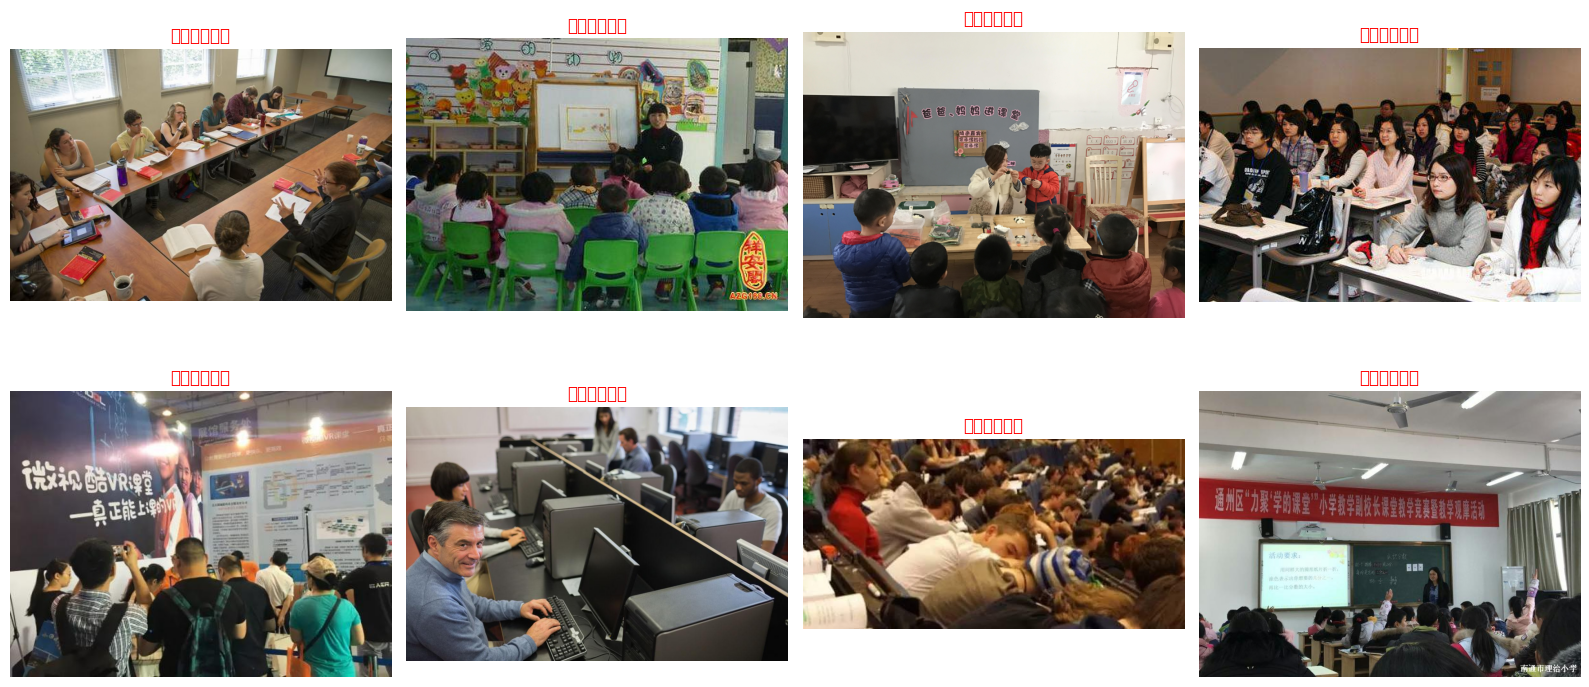

In [5]:
# 可视化样本
def visualize_samples(images, labels, filenames, num_samples=8):
    indices = np.random.choice(len(images), min(num_samples, len(images)), replace=False)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        axes[i].imshow(images[idx])
        label_text = '佩戴安全帽' if labels[idx] == 1 else '未佩戴安全帽'
        color = 'green' if labels[idx] == 1 else 'red'
        axes[i].set_title(f'{label_text}', color=color)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

print("样本展示:")
visualize_samples(all_images, all_labels, all_filenames)

## 4. 提取 DINOv3 特征

In [8]:
# 图像预处理
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def extract_features(model, images, batch_size=32):
    """
    使用 DINOv3 提取图像特征
    
    Returns:
        features: [N, D] 特征矩阵
    """
    all_features = []
    
    print(f"提取 {len(images)} 张图像的特征...")
    
    for i in tqdm(range(0, len(images), batch_size)):
        batch_images = images[i:i+batch_size]
        
        # 预处理
        batch_tensors = torch.stack([transform(img) for img in batch_images])
        
        # 提取特征
        with torch.no_grad():
            # CLS token 特征
            features = model(batch_tensors)  # [B, D]
            features = F.normalize(features, p=2, dim=1)  # L2 归一化
        
        all_features.append(features.numpy())
    
    return np.vstack(all_features)

In [9]:
# 提取特征
features = extract_features(model, all_images)

print(f"\n特征形状: {features.shape}")
print(f"特征维度: {features.shape[1]}")
print(f"特征范围: [{features.min():.4f}, {features.max():.4f}]")

提取 104 张图像的特征...


100%|██████████| 4/4 [01:47<00:00, 26.90s/it]


特征形状: (104, 1024)
特征维度: 1024
特征范围: [-0.1571, 0.1707]


## 5. 划分训练集和测试集

In [10]:
from sklearn.model_selection import train_test_split

# 划分数据集
X_train, X_test, y_train, y_test, files_train, files_test = train_test_split(
    features, all_labels, all_filenames, 
    test_size=0.2, 
    random_state=42,
    stratify=all_labels  # 保持类别比例
)

print(f"数据集划分:")
print(f"  训练集: {len(X_train)} 张")
print(f"    - 佩戴安全帽: {sum(y_train)} 张")
print(f"    - 未佩戴安全帽: {len(y_train) - sum(y_train)} 张")
print(f"  测试集: {len(X_test)} 张")
print(f"    - 佩戴安全帽: {sum(y_test)} 张")
print(f"    - 未佩戴安全帽: {len(y_test) - sum(y_test)} 张")

数据集划分:
  训练集: 83 张
    - 佩戴安全帽: 17 张
    - 未佩戴安全帽: 66 张
  测试集: 21 张
    - 佩戴安全帽: 4 张
    - 未佩戴安全帽: 17 张


## 6. 训练分类器

比较多种分类器的效果。

In [11]:
def train_and_evaluate_classifier(clf, clf_name, X_train, y_train, X_test, y_test):
    """训练并评估分类器"""
    # 训练
    clf.fit(X_train, y_train)
    
    # 预测
    y_pred = clf.predict(X_test)
    
    # 评估
    acc = accuracy_score(y_test, y_pred)
    
    print(f"\n{clf_name}:")
    print(f"  准确率: {acc:.2%}")
    
    # 交叉验证
    cv_scores = cross_val_score(clf, X_train, y_train, cv=5)
    print(f"  交叉验证: {cv_scores.mean():.2%} (+/- {cv_scores.std()*2:.2%})")
    
    return clf, acc, y_pred

# 定义多个分类器
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, probability=True),
    'SVM (Linear)': SVC(kernel='linear', C=1.0, probability=True),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, clf in classifiers.items():
    clf_copy = type(clf)(**clf.get_params())
    results[name] = train_and_evaluate_classifier(clf_copy, name, X_train, y_train, X_test, y_test)


Logistic Regression:
  准确率: 95.24%
  交叉验证: 96.47% (+/- 9.41%)

SVM (RBF):
  准确率: 100.00%
  交叉验证: 98.82% (+/- 4.71%)

SVM (Linear):
  准确率: 100.00%
  交叉验证: 100.00% (+/- 0.00%)

KNN (k=5):
  准确率: 100.00%
  交叉验证: 100.00% (+/- 0.00%)

Random Forest:
  准确率: 95.24%
  交叉验证: 98.82% (+/- 4.71%)


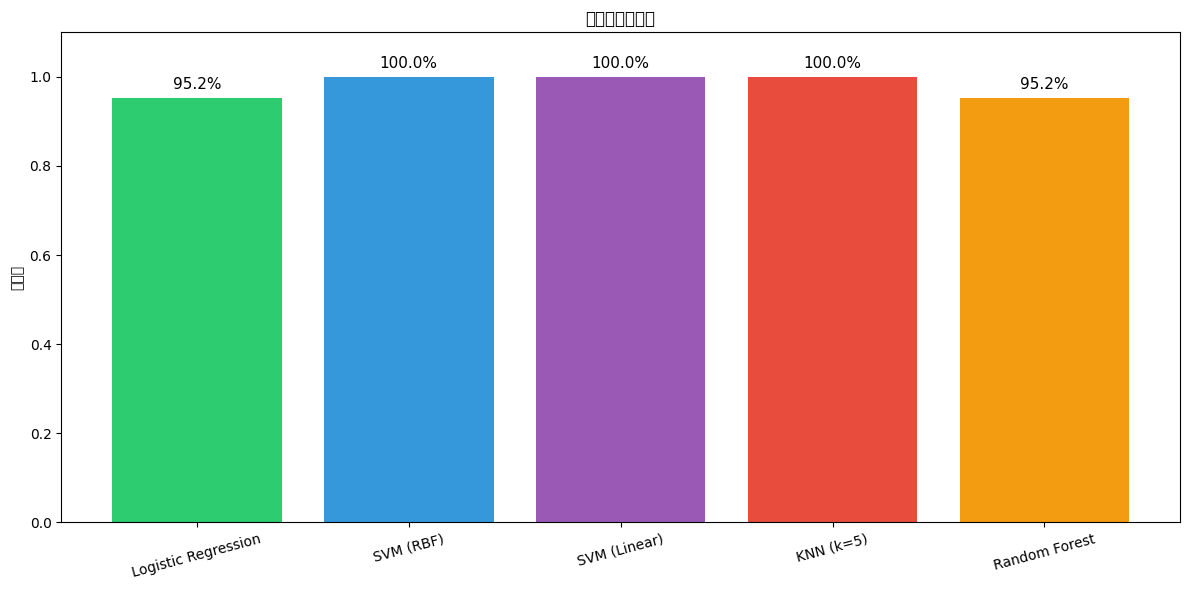


最佳分类器: SVM (RBF) (准确率: 100.00%)


In [12]:
# 比较分类器性能
names = list(results.keys())
accuracies = [results[name][1] for name in names]

plt.figure(figsize=(12, 6))
bars = plt.bar(names, accuracies, color=['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12'])
plt.ylabel('准确率')
plt.title('分类器性能对比')
plt.ylim(0, 1.1)
plt.xticks(rotation=15)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{acc:.1%}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# 选择最佳分类器
best_name = max(results, key=lambda x: results[x][1])
print(f"\n最佳分类器: {best_name} (准确率: {results[best_name][1]:.2%})")

## 7. 集成分类器（推荐）

使用投票法集成多个分类器，通常能获得更好的效果。

In [13]:
# 创建集成分类器
ensemble = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, C=1.0)),
        ('svm_rbf', SVC(kernel='rbf', C=1.0, probability=True)),
        ('svm_linear', SVC(kernel='linear', C=1.0, probability=True)),
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
    ],
    voting='soft'  # 软投票，使用概率
)

# 训练
print("训练集成分类器...")
ensemble.fit(X_train, y_train)

# 评估
y_pred_ensemble = ensemble.predict(X_test)
acc_ensemble = accuracy_score(y_test, y_pred_ensemble)

print(f"\n集成分类器准确率: {acc_ensemble:.2%}")
print(f"\n分类报告:")
print(classification_report(y_test, y_pred_ensemble, target_names=['未佩戴安全帽', '佩戴安全帽']))

训练集成分类器...

集成分类器准确率: 100.00%

分类报告:
              precision    recall  f1-score   support

      未佩戴安全帽       1.00      1.00      1.00        17
       佩戴安全帽       1.00      1.00      1.00         4

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



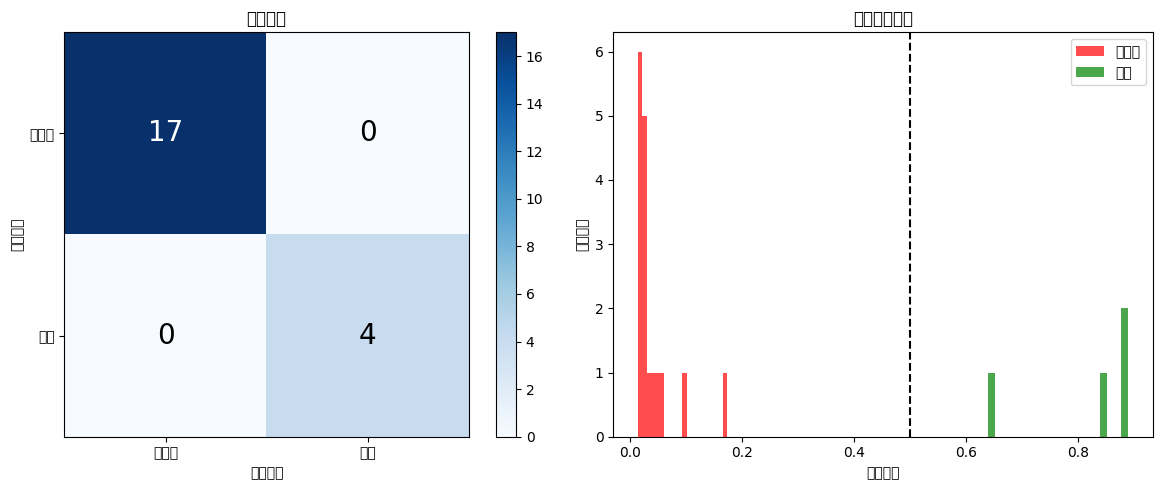

In [14]:
# 混淆矩阵
cm = confusion_matrix(y_test, y_pred_ensemble)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 混淆矩阵热图
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['未佩戴', '佩戴'])
axes[0].set_yticklabels(['未佩戴', '佩戴'])
axes[0].set_xlabel('预测标签')
axes[0].set_ylabel('真实标签')
axes[0].set_title('混淆矩阵')

for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=20,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.colorbar(im, ax=axes[0])

# 预测概率分布
y_proba = ensemble.predict_proba(X_test)[:, 1]

axes[1].hist(y_proba[np.array(y_test)==0], bins=20, alpha=0.7, label='未佩戴', color='red')
axes[1].hist(y_proba[np.array(y_test)==1], bins=20, alpha=0.7, label='佩戴', color='green')
axes[1].set_xlabel('预测概率')
axes[1].set_ylabel('样本数量')
axes[1].set_title('预测概率分布')
axes[1].legend()
axes[1].axvline(x=0.5, color='black', linestyle='--')

plt.tight_layout()
plt.show()

## 8. 保存模型

In [15]:
# 保存集成分类器
model_data = {
    'classifier': ensemble,
    'feature_dim': features.shape[1],
    'classes': {0: '未佩戴安全帽', 1: '佩戴安全帽'},
    'accuracy': acc_ensemble,
    'train_samples': len(X_train),
    'test_samples': len(X_test),
}

with open(CLASSIFIER_PATH, 'wb') as f:
    pickle.dump(model_data, f)

print(f"✓ 模型已保存至: {CLASSIFIER_PATH}")
print(f"  准确率: {acc_ensemble:.2%}")
print(f"  训练样本: {len(X_train)}")
print(f"  测试样本: {len(X_test)}")

✓ 模型已保存至: d:\AI\Git\dinov3.git\notebooks\safety_helmet_classifier.pkl
  准确率: 100.00%
  训练样本: 83
  测试样本: 21


## 9. 推理接口

提供便捷的推理函数。

In [16]:
class SafetyHelmetClassifier:
    """安全帽分类器"""
    
    def __init__(self, model_path, dinov3_model, transform):
        """
        初始化分类器
        
        Args:
            model_path: 分类器模型路径
            dinov3_model: DINOv3 模型
            transform: 图像预处理
        """
        with open(model_path, 'rb') as f:
            self.model_data = pickle.load(f)
        
        self.classifier = self.model_data['classifier']
        self.classes = self.model_data['classes']
        self.dinov3_model = dinov3_model
        self.transform = transform
        
        print(f"✓ 分类器加载完成")
        print(f"  准确率: {self.model_data['accuracy']:.2%}")
        print(f"  类别: {self.classes}")
    
    def extract_feature(self, image):
        """提取单张图像的特征"""
        image_tensor = self.transform(image).unsqueeze(0)
        
        with torch.no_grad():
            feature = self.dinov3_model(image_tensor)
            feature = F.normalize(feature, p=2, dim=1)
        
        return feature.numpy()
    
    def predict_single(self, image):
        """
        预测单张图像
        
        Args:
            image: PIL Image 或图像路径
        
        Returns:
            prediction: 预测类别 (0 或 1)
            label: 预测标签文字
            probability: 预测概率
        """
        if isinstance(image, str):
            image = Image.open(image).convert('RGB')
        
        feature = self.extract_feature(image)
        
        prediction = self.classifier.predict(feature)[0]
        probability = self.classifier.predict_proba(feature)[0]
        
        return {
            'prediction': int(prediction),
            'label': self.classes[prediction],
            'probability': probability[prediction],
            'probabilities': {self.classes[i]: prob for i, prob in enumerate(probability)}
        }
    
    def predict_batch(self, image_paths, visualize=False):
        """
        批量预测多张图像
        
        Args:
            image_paths: 图像路径列表
            visualize: 是否可视化
        
        Returns:
            results: 预测结果列表
        """
        results = []
        
        for path in image_paths:
            try:
                result = self.predict_single(path)
                result['image_path'] = path
                results.append(result)
            except Exception as e:
                print(f"错误: {path} - {e}")
        
        if visualize:
            self._visualize_results(results)
        
        return results
    
    def _visualize_results(self, results, num_samples=8):
        """可视化预测结果"""
        n = min(len(results), num_samples)
        
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        axes = axes.flatten()
        
        for i, r in enumerate(results[:n]):
            img = Image.open(r['image_path'])
            axes[i].imshow(img)
            
            color = 'green' if r['prediction'] == 1 else 'red'
            axes[i].set_title(f"{r['label']}\n({r['probability']:.1%})", color=color)
            axes[i].axis('off')
        
        for i in range(n, 8):
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()

# 创建分类器实例
classifier = SafetyHelmetClassifier(CLASSIFIER_PATH, model, transform)

print("\n使用方法:")
print("  # 单张图片")
print("  result = classifier.predict_single('image.jpg')")
print("  print(result)")
print()
print("  # 多张图片")
print("  results = classifier.predict_batch(['img1.jpg', 'img2.jpg'], visualize=True)")

✓ 分类器加载完成
  准确率: 100.00%
  类别: {0: '未佩戴安全帽', 1: '佩戴安全帽'}

使用方法:
  # 单张图片
  result = classifier.predict_single('image.jpg')
  print(result)

  # 多张图片
  results = classifier.predict_batch(['img1.jpg', 'img2.jpg'], visualize=True)


测试推理:


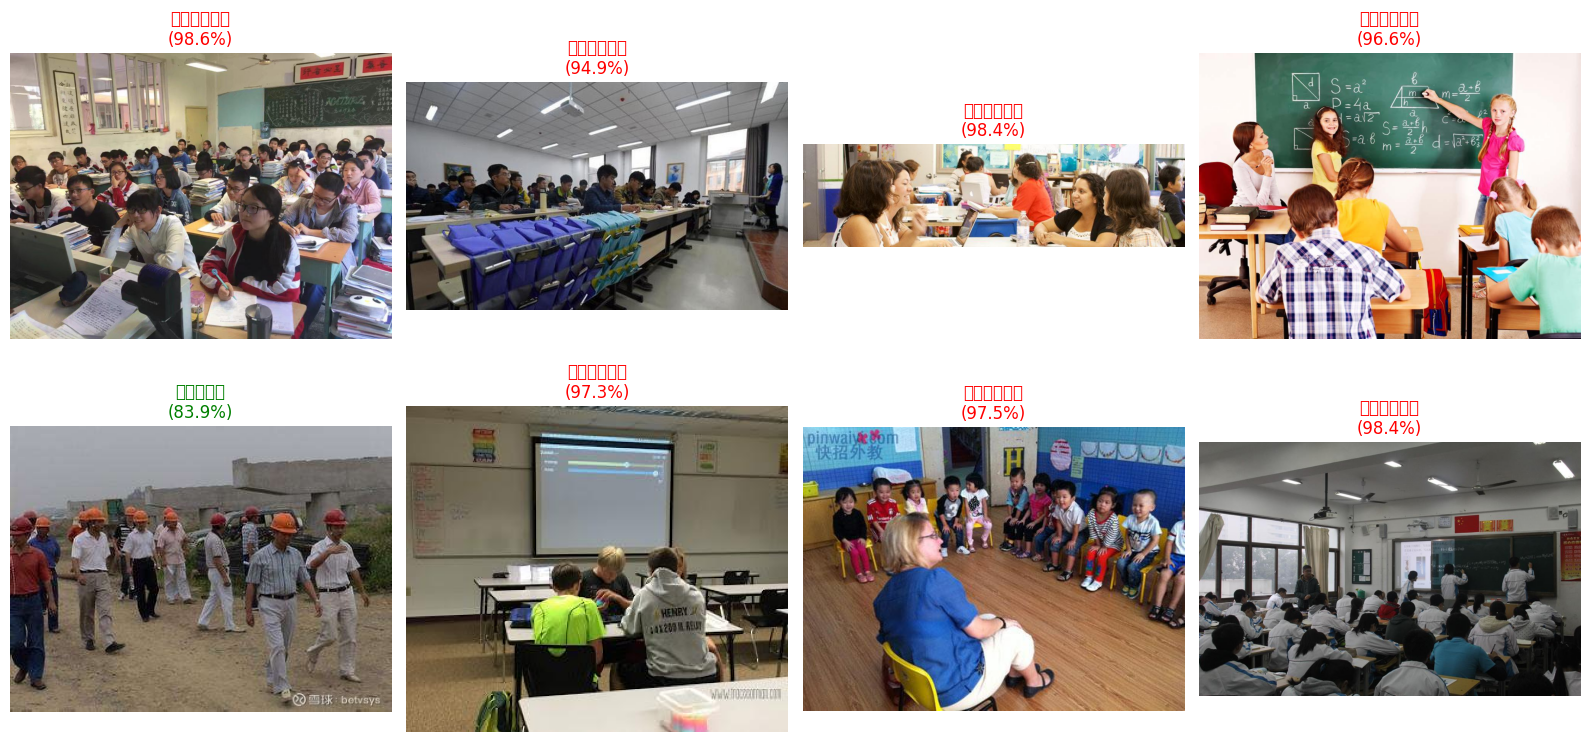


PartB_00025.jpg:
  预测: 未佩戴安全帽
  置信度: 98.57%
  各类概率: {'未佩戴安全帽': 0.9857414176444059, '佩戴安全帽': 0.014258582355594084}

PartB_01081.jpg:
  预测: 未佩戴安全帽
  置信度: 94.88%
  各类概率: {'未佩戴安全帽': 0.94876894347294, '佩戴安全帽': 0.05123105652706002}

PartB_00710.jpg:
  预测: 未佩戴安全帽
  置信度: 98.43%
  各类概率: {'未佩戴安全帽': 0.9842736970068451, '佩戴安全帽': 0.015726302993154865}

PartB_00323.jpg:
  预测: 未佩戴安全帽
  置信度: 96.60%
  各类概率: {'未佩戴安全帽': 0.9660008018829682, '佩戴安全帽': 0.03399919811703182}

000250.jpg:
  预测: 佩戴安全帽
  置信度: 83.95%
  各类概率: {'未佩戴安全帽': 0.16054815610603593, '佩戴安全帽': 0.839451843893964}

PartB_00795.jpg:
  预测: 未佩戴安全帽
  置信度: 97.29%
  各类概率: {'未佩戴安全帽': 0.9729028499675115, '佩戴安全帽': 0.027097150032488547}

PartB_00444.jpg:
  预测: 未佩戴安全帽
  置信度: 97.48%
  各类概率: {'未佩戴安全帽': 0.974807030182221, '佩戴安全帽': 0.025192969817778965}

PartB_00030.jpg:
  预测: 未佩戴安全帽
  置信度: 98.40%
  各类概率: {'未佩戴安全帽': 0.9839943210065579, '佩戴安全帽': 0.01600567899344218}


In [18]:
# 测试推理
# 从测试集中随机选择几张图片
test_indices = np.random.choice(len(files_test), min(8, len(files_test)), replace=False)
test_images = [files_test[i] for i in test_indices]

print("测试推理:")
results = classifier.predict_batch(test_images, visualize=True)

# 打印详细结果
for r in results:
    print(f"\n{os.path.basename(r['image_path'])}:")
    print(f"  预测: {r['label']}")
    print(f"  置信度: {r['probability']:.2%}")
    print(f"  各类概率: {r['probabilities']}")

## 10. 自定义测试

In [ ]:
# 自定义图片测试
custom_images = [
    # 在这里添加你的图片路径
    r"D:\AI\Datasets\safetyhelmet_detection_for_train\images/000328.jpg",
    r"D:\AI\Datasets\safetyhelmet_detection_for_train\images/000331.jpg",
    r"D:\AI\Datasets\safetyhelmet_detection_for_train\images/000676.jpg",
    r"D:\AI\Datasets\safetyhelmet_detection_for_train\images/PartB_00444.jpg",
    r"D:\AI\Datasets\safetyhelmet_detection_for_train\images/PartB_02092.jpg",
    r"D:\AI\Datasets\safetyhelmet_detection_for_train\images/PartB_02314.jpg"
]

if custom_images:
    print("自定义图片测试:")
    results = classifier.predict_batch(custom_images, visualize=True)
else:
    print("请在 custom_images 列表中添加图片路径进行测试")

## 总结

### 完成的工作
1. ✅ 加载 DINOv3 预训练模型
2. ✅ 从文件夹加载自定义数据集
3. ✅ 使用 DINOv3 提取图像特征
4. ✅ 训练多种分类器并比较性能
5. ✅ 保存最佳模型
6. ✅ 提供便捷的推理接口

### 使用方法
```python
# 加载分类器
classifier = SafetyHelmetClassifier(
    model_path="safety_helmet_classifier.pkl",
    dinov3_model=model,
    transform=transform
)

# 预测单张图片
result = classifier.predict_single("image.jpg")

# 批量预测
results = classifier.predict_batch(["img1.jpg", "img2.jpg"])
```

### 改进方向
1. **数据增强**：增加训练样本的多样性
2. **特征融合**：结合多层特征或 patch 特征
3. **难例挖掘**：关注分类错误的样本
4. **在线学习**：持续收集数据更新模型